# Fashion MNIST Model

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -qU lightning timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.5/808.5 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 18.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 22.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.3/812.3 kB 26.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 65.6 MB/s eta 0:00:00


In [3]:
import os, gc, sys, copy, pickle
from pathlib import Path
from collections import defaultdict, Counter
import glob
from tqdm.auto import tqdm
tqdm.pandas()

import math
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision import datasets

import lightning as pl
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint, StochasticWeightAveraging
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

import timm

import cv2
cv2.setNumThreads(0)
import PIL
from IPython import display
import warnings
warnings.filterwarnings("ignore")
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Seed for reproducibility

In [4]:
def seeding(SEED):
    np.random.seed(SEED)
    random.seed(SEED)
    os.environ['PYTHONHASHSEED'] = str(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
    print('seeding done!!!')

def flush():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

# Configuration

In [5]:
CONFIG = dict(
    seed = 42,
    backbone = "tf_efficientnet_b0.ns_jft_in1k", # convnext_base.fb_in1k,

    drop_rate = 0,
    drop_rate_last = 0.3,
    drop_rate_path = 0.,
    in_chans=1,
    out_dim = 10,
    batch_size = 32,
    img_size = 224,
    lr = 1e-3,
    epochs = 4,
    # device = torch.device("cuda:0") if torch.cuda.is_available() else "cpu"
)

seeding(CONFIG['seed'])

seeding done!!!


In [6]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26421880/26421880 [00:06<00:00, 3795474.55it/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 200028.89it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:01<00:00, 3915321.22it/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 19809428.43it/s]


Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



# Visualize images

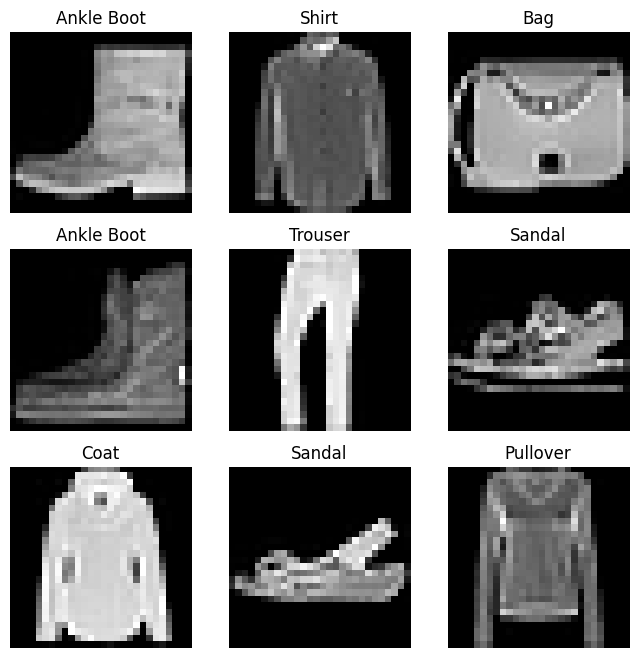

In [7]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [8]:
# create dataloaders
train_dataloader = DataLoader(training_data, batch_size=CONFIG['batch_size'], shuffle=True,
                              num_workers=os.cpu_count(), drop_last=True, pin_memory=True)

valid_dataloader = DataLoader(test_data, batch_size=2*CONFIG['batch_size'], shuffle=False,
                              num_workers=os.cpu_count(), drop_last=False, pin_memory=True)

In [9]:
b = next(iter(train_dataloader))

# Create custom model

In [10]:
class FashionModel(nn.Module):
    def __init__(self, backbone, pretrained=False):
        super(FashionModel, self).__init__()
        self.encoder = timm.create_model(
            backbone,
            in_chans=CONFIG['in_chans'],
            features_only=False,
            drop_rate=CONFIG['drop_rate'],
            drop_path_rate=CONFIG['drop_rate_path'],
            pretrained=pretrained,
        )

        self.nb_fts = self.encoder.num_features
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(self.nb_fts, CONFIG['out_dim'])

    def forward(self, x):
        feat = self.encoder.forward_features(x)
        feat = self.gap(feat)[:,:,0,0]
        y = self.head(feat)

        return y

    def freeze_encoder(self, flag):
        for param in self.encoder.parameters():
            param.requires_grad = not flag

# Pytorch lightning module

### Used for training

In [11]:
class FashionLightningModel(pl.LightningModule):
    def __init__(self, pretrained=False):
        super().__init__()
        self.model = FashionModel(CONFIG['backbone'], pretrained=pretrained)
#         print(WEIGHTS[1])
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, image):
        return self.model(image)

    def shared_step(self, batch, stage):
        images, labels = batch[0], batch[1]
        logits = self.forward(images)
        loss = self.loss_fn(logits, labels)
        preds = logits.softmax(dim=-1)
        self.log(f"{stage}_loss", loss, on_step=True, on_epoch=True, prog_bar=True)

        outputs = {
            "loss": loss,
            "preds": preds
        }
        return outputs


    def training_step(self, batch, batch_idx):
        return self.shared_step(batch, stage='train')

    def validation_step(self, batch, batch_idx):
        return self.shared_step(batch, stage='valid')

    def predict_step(self, batch):
        inputs, targets = batch[0], batch[1]
        return self.forward(inputs).softmax(dim=-1)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=CONFIG['lr'])
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"], eta_min=0)
        return [optimizer], [scheduler]

In [12]:
os.makedirs(f'{os.getcwd()}/drive/MyDrive/FashionMNIST', exist_ok=True)

In [13]:
net = FashionLightningModel(pretrained=False)
callbacks = [
    ModelCheckpoint(save_weights_only=True,
                    mode="min",
                    monitor="valid_loss"),
    LearningRateMonitor("epoch"),
]

trainer = pl.Trainer(accelerator="gpu", devices=1,
                    precision="16-mixed",
                    max_epochs=CONFIG['epochs'],
                    callbacks=callbacks, default_root_dir=f"{os.getcwd()}/drive/MyDrive/FashionMNIST/")
# trainer = pl.Trainer(fast_dev_run=10)
trainer.fit(net, train_dataloaders=train_dataloader, val_dataloaders=valid_dataloader)

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | model   | FashionModel     | 5.3 M  | train
1 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
5.3 M     Trainable params
0         Non-trainable params
5.3 M     Total params
21.203    Tot

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=4` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=4` reached.


In [14]:
predictions = trainer.predict(net, valid_dataloader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [15]:
len(predictions), len(valid_dataloader)

(157, 157)

In [17]:
b = next(iter(valid_dataloader))
b[0].shape, predictions[0].shape

(torch.Size([64, 1, 28, 28]), torch.Size([64, 10]))

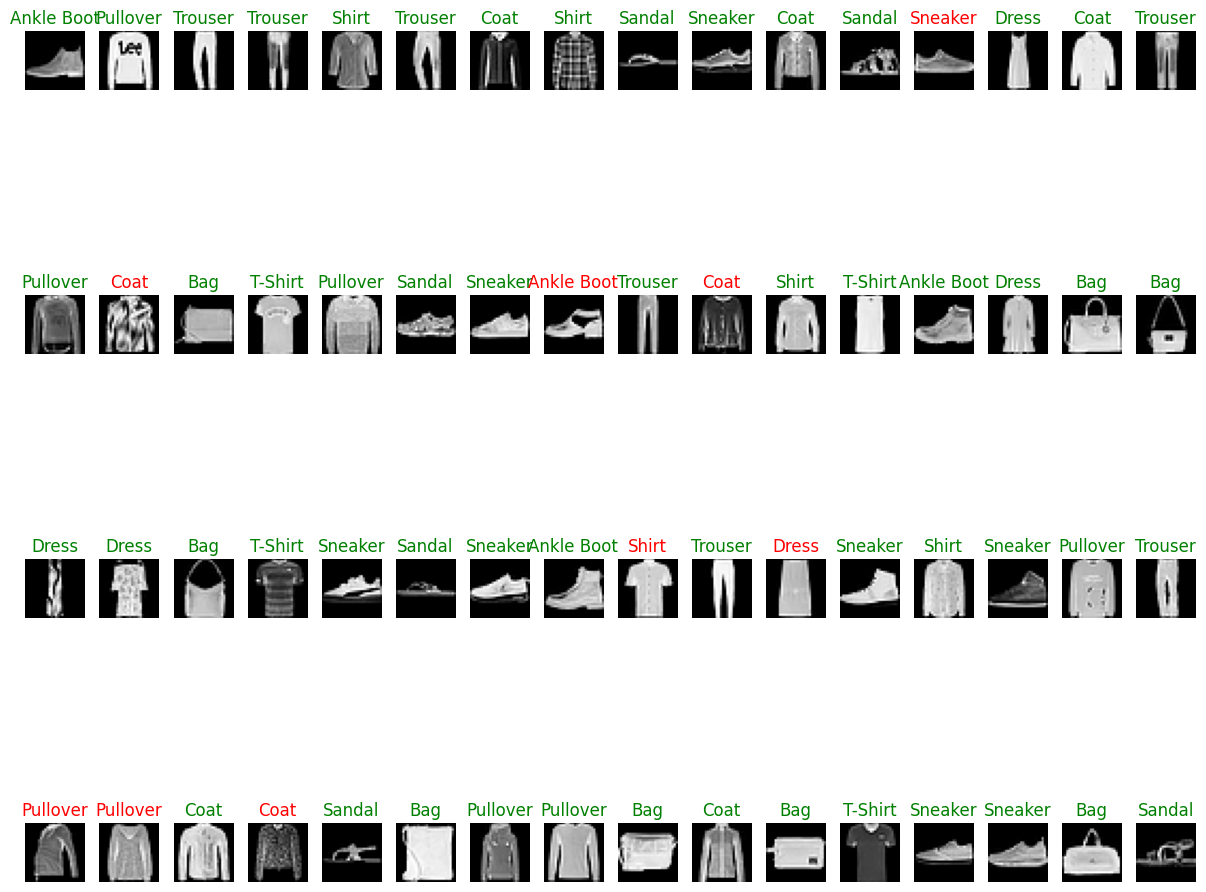

In [35]:
def visualize_predictions(images, y_true, y_preds, show_name=True):
    fig, axes = plt.subplots(nrows=4, ncols=16, figsize=(12, 12))
    axes = axes.flatten()

    for i in range(len(images)):
        img = images[i].squeeze()
        # img = img.permute(1, 2, 0)
        img = (img * 255).numpy().astype(np.uint8)
        axes[i].imshow(img, cmap='gray')
        color = "green" if y_true[i] == torch.argmax(y_preds[i], dim=-1) else "red"
        label = labels_map[y_true[i].item()]
        if show_name:
            axes[i].set_title(label, color=color)
        else:
            axes[i].set_title(f"True: {y_true[i]}\nPred: {torch.argmax(y_preds[i], dim=-1)}", color=color)
        axes[i].axis('off')

    fig.tight_layout()
    plt.show()

visualize_predictions(b[0], b[1], predictions[0])